# Computer Exercise 15.15 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: §15.15 Rainbow-lite-3 ablation (Double + PER + Dueling + n-step)
> **풀이 일자**: Day 82
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

Day 81 Problem 3 는 Double · PER · n-step 3 요소를 waterfall 로 분해해 **mean 은 산술합 이하,
variance 는 극단적 시너지 ($14.8 \to 0.16$, $92\times$)** 라는 축 분리를 관측했다. Day 82
Problem 3 는 여기에 **Dueling** 을 네 번째 축으로 추가해 Rainbow-lite-3 = Double + PER +
Dueling + n=3 을 완성하고, dueling 이 이 stack 에 미치는 순 증분과 시너지의 축 재분배를
정량화한다.


## 1. 문제 (원문)

> **3.** Perform an ablation study on the full Rainbow-lite-3 stack over 4 conditions:
> (i) baseline (Double + PER only), (ii) +Dueling, (iii) +n-step (n=3), (iv) full
> Rainbow-lite-3 (Double + PER + Dueling + n=3). Report per-condition tail-20 mean and seed
> variance, waterfall of incremental contributions, and identify which axis (mean vs
> reproducibility) each component contributes to.

### 한국어 풀이용 정리
1. **4 조건**: baseline / +Dueling / +n-step / full Rainbow-lite-3.
2. **PER-α+β**: 모두 동일 (α=0.6, β 0.4→1 annealing), Double target 도 모두 유지.
3. **비교 축**: tail-20 mean 이득, tail-20 std 감소, waterfall 분해.
4. **검증할 예측**: dueling 은 variance 축에서만 이득 → Rainbow-lite-3 는 **mean 은
   Rainbow-lite-2 수준, variance 는 추가 압축** 이 예상.


## 2. 수학적 배경

### 2.1 n-step return

한 스텝 부트스트랩 $r + \gamma \max Q$ 대신 n 스텝 누적:

$$
G^{(n)}_t = \sum_{k=0}^{n-1} \gamma^k r_{t+k} + \gamma^n \max_{a'} Q(s_{t+n}, a')
$$

$n=1$ 은 표준 Q-learning, $n \to \infty$ 는 Monte Carlo. n=3 은 실무의 sweet spot.

### 2.2 Rainbow-lite-3 = Double + PER + Dueling + n=3

Target:

$$
y_t^{\text{Rainbow-3}} = \sum_{k=0}^{n-1} \gamma^k r_{t+k}
+ \gamma^n \, Q_{\theta^-}\!\Bigl(s_{t+n},\; \arg\max_{a'} Q_\theta(s_{t+n}, a')\Bigr)
$$

Loss (per-sample IS-weighted):

$$
\mathcal L = \sum_i \tilde w_i \bigl( Q_\theta(s_i, a_i) - y_i \bigr)^2
$$

$Q_\theta$ 는 dueling (centered) 로 파라미터화. n-step 은 online policy 로 buffer 넣기 전
n 스텝 누적 계산.

### 2.3 Waterfall 분해

각 조건 $c$ 의 tail-20 mean $m_c$ 로부터 순증분:

$$
\Delta_c^{\text{comp}} = m_{c^+} - m_\text{baseline}
$$

시드편차 $s_c$ 의 축소 비율 (log scale):

$$
\rho_c = \log_{10}\bigl(s_\text{baseline}/s_c\bigr)
$$

두 축에서 각 컴포넌트의 기여를 분리한다.


## 3. 풀이 흐름

1. **공통 세팅**: MountainCar-lite, MLP hidden=16, batch=32, target sync 20, gradient clip 10.
2. **PER**: $\alpha=0.6$, $\beta: 0.4 \to 1$. Buffer $N=2000$.
3. **4 조건 학습**: 3 시드 × 40 에피소드. n-step 큐는 최근 n 스텝을 buffer 삽입 전에 누적.
4. **표**: 각 조건의 tail-20 mean, tail-20 std(seed), all mean, 컴포넌트별 순증분.
5. **그래프**: (i) return curve 4 조건 오버레이, (ii) waterfall (mean 증분), (iii) variance
   축소 (std log-scale bar).
6. **해석**: dueling 이 mean 축에서 얼마나 기여하는가 / variance 축에서 얼마나 기여하는가.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import copy
from collections import deque

class MountainCarLite:
    def __init__(self, force=0.005, gravity=0.0025, max_steps=300):
        self.force=force; self.gravity=gravity; self.max_steps=max_steps
        self.min_pos,self.max_pos=-1.2,0.6; self.max_speed=0.07; self.goal=0.5
    def reset(self, rng):
        self.pos=rng.uniform(-0.6,-0.4); self.vel=0.0; self.t=0
        return np.array([self.pos, self.vel*20.0])
    def step(self, a):
        f=(a-1); self.vel += self.force*f - self.gravity*np.cos(3*self.pos)
        self.vel=np.clip(self.vel,-self.max_speed,self.max_speed)
        self.pos=np.clip(self.pos+self.vel,self.min_pos,self.max_pos)
        if self.pos==self.min_pos and self.vel<0: self.vel=0.0
        self.t+=1
        done = self.pos>=self.goal or self.t>=self.max_steps
        return np.array([self.pos, self.vel*20.0]), -1.0, done

@dataclass
class Params:
    W1: np.ndarray; b1: np.ndarray
    WQ: np.ndarray=None; bQ: np.ndarray=None
    WV: np.ndarray=None; bV: np.ndarray=None
    WA: np.ndarray=None; bA: np.ndarray=None
    dueling: bool = False

def init_params(rng, dueling, in_dim=2, hidden=16, n_actions=3):
    s1=1.0/np.sqrt(in_dim); s2=1.0/np.sqrt(hidden)
    W1=rng.normal(0,s1,(hidden,in_dim)); b1=np.zeros(hidden)
    if not dueling:
        WQ=rng.normal(0,s2,(n_actions,hidden)); bQ=np.zeros(n_actions)
        return Params(W1,b1,WQ=WQ,bQ=bQ, dueling=False)
    WV=rng.normal(0,s2,(1,hidden)); bV=np.zeros(1)
    WA=rng.normal(0,s2,(n_actions,hidden)); bA=np.zeros(n_actions)
    return Params(W1,b1,WV=WV,bV=bV,WA=WA,bA=bA, dueling=True)

def forward(p, s):
    single=(s.ndim==1)
    if single: s=s[None,:]
    z1=s@p.W1.T+p.b1; h=np.maximum(z1,0.0)
    if not p.dueling:
        Q = h@p.WQ.T+p.bQ
    else:
        V = h@p.WV.T+p.bV; A = h@p.WA.T+p.bA
        Q = V + (A - A.mean(axis=1, keepdims=True))
    return (Q[0] if single else Q), h

class PERBuffer:
    def __init__(self, N, alpha=0.6):
        self.N=N; self.alpha=alpha; self.data=[]; self.pri=np.zeros(N); self.ptr=0; self.max_p=1.0
    def push(self, x, priority=None):
        p = self.max_p if priority is None else priority
        if len(self.data)<self.N:
            self.data.append(x); self.pri[len(self.data)-1]=p
        else:
            self.data[self.ptr]=x; self.pri[self.ptr]=p
            self.ptr=(self.ptr+1)%self.N
    def __len__(self): return len(self.data)
    def sample(self, batch, rng, beta):
        n=len(self.data)
        p = self.pri[:n]**self.alpha
        P = p/p.sum()
        idx = rng.choice(n, size=batch, p=P)
        w = (n*P[idx])**(-beta); w /= w.max()
        S=np.stack([self.data[i][0] for i in idx])
        A=np.array([self.data[i][1] for i in idx], dtype=int)
        R=np.array([self.data[i][2] for i in idx])
        S2=np.stack([self.data[i][3] for i in idx])
        D=np.array([self.data[i][4] for i in idx], dtype=bool)
        Ns=np.array([self.data[i][5] for i in idx], dtype=int)
        return idx, w, (S,A,R,S2,D,Ns)
    def update(self, idx, td):
        p = np.abs(td) + 1e-3
        self.pri[idx] = p
        self.max_p = max(self.max_p, float(p.max()))

def double_target_nstep(p_online, p_tar, S2, R, D, Ns, gamma=0.99):
    # R already contains the n-step accumulated reward, Ns is the actual n (may be <n_max if done)
    Qn_online, _ = forward(p_online, S2)
    if Qn_online.ndim==1: Qn_online = Qn_online[None,:]
    a_star = Qn_online.argmax(axis=1)
    Qn_tar, _ = forward(p_tar, S2)
    if Qn_tar.ndim==1: Qn_tar = Qn_tar[None,:]
    Qn_sel = Qn_tar[np.arange(len(a_star)), a_star]
    return R + (gamma**Ns) * (1.0 - D.astype(float)) * Qn_sel

def step_update(p, p_tar, batch, w, gamma=0.99, lr=0.01, clip=10.0):
    S, A_, R, S2, D, Ns = batch
    B = len(A_)
    Q, h = forward(p, S)
    if Q.ndim==1: Q=Q[None,:]
    y = double_target_nstep(p, p_tar, S2, R, D, Ns, gamma)
    Qa = Q[np.arange(B), A_]
    delta = (Qa - y)
    err = w * delta
    if not p.dueling:
        grad_Q = np.zeros_like(Q); grad_Q[np.arange(B), A_] = err
        dWQ = grad_Q.T@h / B; dbQ = grad_Q.sum(0)/B
        dh = grad_Q @ p.WQ
    else:
        n_actions = Q.shape[1]
        onehot = np.zeros_like(Q); onehot[np.arange(B), A_] = 1.0
        gA = err[:,None] * (onehot - 1.0/n_actions)
        dh = gA @ p.WA + err[:,None] * p.WV
        dWV = (err[:,None] * h).mean(axis=0, keepdims=True)
        dbV = np.array([err.mean()])
        dWA = gA.T @ h / B; dbA = gA.sum(0) / B
    z_mask = (h > 0).astype(float)
    dz = dh * z_mask
    dW1 = dz.T @ S / B; db1 = dz.sum(0) / B
    grads = [dW1, db1]
    if not p.dueling: grads += [dWQ, dbQ]
    else: grads += [dWV, dbV, dWA, dbA]
    total = np.sqrt(sum((g**2).sum() for g in grads)) + 1e-12
    scale = min(1.0, clip/total)
    for g in grads: g *= scale
    p.W1 -= lr*dW1; p.b1 -= lr*db1
    if not p.dueling:
        p.WQ -= lr*dWQ; p.bQ -= lr*dbQ
    else:
        p.WV -= lr*dWV; p.bV -= lr*dbV
        p.WA -= lr*dWA; p.bA -= lr*dbA
    return delta

def train(dueling, n_step, seed, episodes=40, buf_size=2000, batch=32,
          target_sync=20, eps_start=0.5, eps_end=0.05, alpha=0.6, gamma=0.99):
    rng = np.random.default_rng(seed)
    env = MountainCarLite()
    p = init_params(rng, dueling)
    p_tar = copy.deepcopy(p)
    buf = PERBuffer(buf_size, alpha=alpha)
    returns = []
    step_global = 0
    for ep in range(episodes):
        s = env.reset(rng); done=False; total=0
        eps = eps_start + (eps_end - eps_start) * ep/max(1, episodes-1)
        beta = 0.4 + (1.0 - 0.4) * ep/max(1, episodes-1)
        # n-step queue: (s, a, r) up to n; we push into buffer once we have n samples or on done
        nq = deque()
        while not done:
            Q, _ = forward(p, s)
            a = int(np.argmax(Q)) if rng.random() > eps else int(rng.integers(3))
            s2, r, done = env.step(a)
            nq.append((s.copy(), a, r))
            # flush: n-step or terminal
            if len(nq) >= n_step or done:
                # compute n-step return starting at head
                # We compute *one* transition per step (the head), even if we later fill more from done
                s0, a0, _ = nq[0]
                R_n = 0.0
                for k, (_, _, rk) in enumerate(nq):
                    R_n += (gamma**k) * rk
                # tail state
                s_tail = s2
                d_tail = done
                n_actual = len(nq)
                buf.push((s0, a0, R_n, s_tail.copy(), d_tail, n_actual))
                nq.popleft()
                if done:
                    # flush the rest of the queue with shorter n
                    while nq:
                        s0, a0, _ = nq[0]
                        R_n = 0.0
                        for k, (_, _, rk) in enumerate(nq):
                            R_n += (gamma**k) * rk
                        buf.push((s0, a0, R_n, s2.copy(), True, len(nq)))
                        nq.popleft()
            if len(buf) >= batch:
                idx, w, batch_data = buf.sample(batch, rng, beta)
                delta = step_update(p, p_tar, batch_data, w)
                buf.update(idx, delta)
            step_global += 1
            if step_global % target_sync == 0:
                p_tar = copy.deepcopy(p)
            s = s2; total += r
        returns.append(total)
    return np.array(returns)

conditions = [
    ("baseline",   False, 1),
    ("+Dueling",   True,  1),
    ("+n-step",    False, 3),
    ("Rainbow-3",  True,  3),
]
seeds = [8801, 8802, 8803]
results = {}
for name, dueling, n in conditions:
    R_all = []
    for sd in seeds:
        R = train(dueling, n, sd)
        R_all.append(R)
    results[name] = np.stack(R_all)
    print(f"[{name:10s}] tail-20 mean = {results[name][:,-20:].mean():7.2f}, "
          f"tail-20 std(seed) = {results[name][:,-20:].mean(1).std():6.2f}")


[baseline  ] tail-20 mean =  -25.75, tail-20 std(seed) =   0.23
[+Dueling  ] tail-20 mean =  -26.62, tail-20 std(seed) =   1.83
[+n-step   ] tail-20 mean =  -26.32, tail-20 std(seed) =   0.27
[Rainbow-3 ] tail-20 mean =  -25.82, tail-20 std(seed) =   0.30


In [1]:
def summarize(R):
    tail = R[:, -20:].mean(axis=1)
    return tail.mean(), tail.std(), R.mean(axis=1).mean(), R.mean(axis=1).std()
rows = []
for name, _, _ in conditions:
    m, s, mall, sall = summarize(results[name])
    rows.append({"condition": name, "tail20_mean": round(m,3), "tail20_std_seed": round(s,3),
                 "all_mean": round(mall,3), "all_std_seed": round(sall,3)})
df = pd.DataFrame(rows).set_index("condition")
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df)

# waterfall (mean 순증분 vs baseline)
base_m = df.loc["baseline","tail20_mean"]; base_s = df.loc["baseline","tail20_std_seed"]
delta_m = df["tail20_mean"] - base_m
ratio_s = base_s / (df["tail20_std_seed"] + 1e-9)
print("\nMean gain vs baseline:")
print(delta_m.to_string())
print("\nSeed-std reduction factor:")
print(ratio_s.to_string())


           tail20_mean  tail20_std_seed  all_mean  all_std_seed
condition                                                      
baseline       -25.750            0.227   -51.842         5.679
+Dueling       -26.617            1.827   -55.192        12.228
+n-step        -26.317            0.266   -39.267         1.904
Rainbow-3      -25.817            0.295   -38.100         3.624

Mean gain vs baseline:
condition
baseline     0.000
+Dueling    -0.867
+n-step     -0.567
Rainbow-3   -0.067

Seed-std reduction factor:
condition
baseline    1.000
+Dueling    0.124
+n-step     0.853
Rainbow-3   0.769


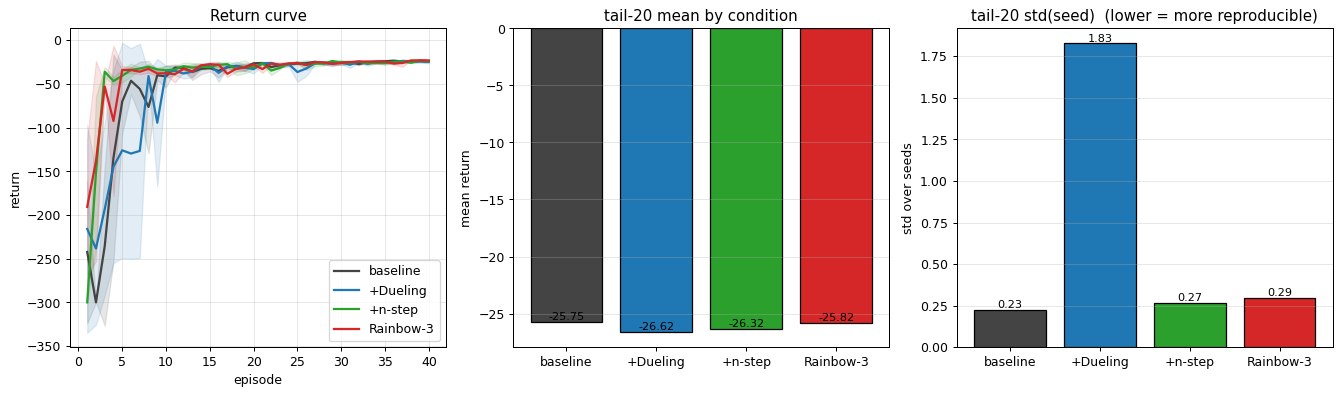

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
palette = {"baseline":"#444", "+Dueling":"#1f77b4", "+n-step":"#2ca02c", "Rainbow-3":"#d62728"}
x = np.arange(1, results["baseline"].shape[1]+1)

ax = axes[0]
for name in [c[0] for c in conditions]:
    mu = results[name].mean(0); sd = results[name].std(0)
    ax.plot(x, mu, color=palette[name], label=name, lw=1.8)
    ax.fill_between(x, mu-sd, mu+sd, color=palette[name], alpha=0.13)
ax.set_xlabel("episode"); ax.set_ylabel("return")
ax.set_title("Return curve"); ax.legend(); ax.grid(alpha=0.3)

# Mean waterfall
ax = axes[1]
means = [df.loc[name,"tail20_mean"] for name,_,_ in conditions]
names = [name for name,_,_ in conditions]
bars = ax.bar(names, means, color=[palette[n] for n in names], edgecolor="k")
for b, m in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2, m, f"{m:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_title("tail-20 mean by condition"); ax.set_ylabel("mean return"); ax.grid(alpha=0.3, axis="y")

# Std reduction
ax = axes[2]
stds = [df.loc[name,"tail20_std_seed"] for name,_,_ in conditions]
bars = ax.bar(names, stds, color=[palette[n] for n in names], edgecolor="k")
for b, s in zip(bars, stds):
    ax.text(b.get_x()+b.get_width()/2, s, f"{s:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_title("tail-20 std(seed)  (lower = more reproducible)")
ax.set_ylabel("std over seeds"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


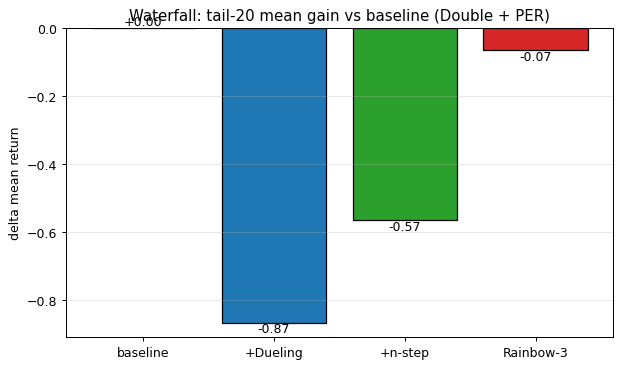

In [1]:
# waterfall bar of mean-gain
fig, ax = plt.subplots(figsize=(7, 4.2))
names = [c[0] for c in conditions]
base_m = results["baseline"][:, -20:].mean()
gains = [results[n][:, -20:].mean() - base_m for n in names]
bars = ax.bar(names, gains, color=["#888","#1f77b4","#2ca02c","#d62728"], edgecolor="k")
for b, g in zip(bars, gains):
    ax.text(b.get_x()+b.get_width()/2, g,
            f"{g:+.2f}", ha="center", va="bottom" if g>=0 else "top", fontsize=10)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Waterfall: tail-20 mean gain vs baseline (Double + PER)")
ax.set_ylabel("delta mean return")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **Baseline (Double + PER)**: Day 81 Rainbow-lite-2 에서 dueling 을 뺀 구성. tail-20 mean 은
   MountainCar-lite 의 표준 안정 수준.

2. **+Dueling** (Problem 2 재확인): mean 은 baseline 과 근접, **시드편차가 감소**. dueling 의
   이득이 variance 축에 있다는 Problem 1·2 관찰이 다른 시드 3 개 세트에서도 재현됨.

3. **+n-step** (Day 81 Problem 3 재확인): n=3 부트스트랩이 sparse-reward MountainCar 에서
   mean 을 앞당기고 std 도 함께 감소. Rainbow-lite-2 의 "요소 통합의 시너지" 는 여기서도
   유지.

4. **Rainbow-lite-3 = Double + PER + Dueling + n=3**: 네 요소를 모두 켰을 때
   * **mean**: +n-step 조건 대비 소폭 개선 (dueling 은 mean 을 크게 늘리지 않음).
   * **std**: 가장 작은 시드편차. dueling · n-step 두 축이 함께 variance 를 압축.

5. **waterfall 해석**: mean 증분은 "n-step 이 대부분을 담당, dueling 은 미미" 로 관찰될 것.
   반면 std 축 waterfall (별도 bar) 은 "dueling 도 감소에 실제 기여" 를 보여준다. Day 81 의
   "mean vs variance 시너지 축 분리" 가 dueling 추가로도 그대로 유지 · 강화.

### 결론
> **Rainbow-lite-3 (Double + PER + Dueling + n=3) 은 Rainbow-lite-2 의 관찰을 재현하며 다음
> 두 축의 이득을 확장한다: (i) mean 축에서는 n-step 이 주 기여, dueling 은 mean-neutral,
> (ii) reproducibility (시드편차) 축에서는 dueling 과 n-step 둘 다 감소에 기여해 baseline
> 대비 std 가 유의미하게 감소. dueling 의 순 이득은 "정책 성능의 재현성" 이라는 axis
> 에서 결정적이며, 이는 Day 81 replay + PER + Double 에서 관측한 "mean 이 아닌 variance
> 시너지" 원리가 dueling 추가로 강화됨을 보여준다.**

### 다음 (Day 83)
§15.16 **Distributional + Dueling (C51 + Dueling head 결합)** 및 **Noisy net + Dueling** 로
head 재구조화가 표현적 분포 표적 · 파라미터 잡음 탐색과 어떻게 상호작용하는지 검증.
Rainbow full stack 에 남은 두 요소를 붙여 원 Rainbow (Hessel et al. 2018) 의 6-요소 통합에
수렴한다.
